# Paso 2 — Adquisición y Obtención del Conjunto de Datos
**Sistema de Monitoreo de Calidad del Agua - IDEAM Colombia**

Dataset: `Data_Histórica_de_Calidad_de_Agua_20260528.csv`  
Registros totales: ~134.263 | Formato: largo (una fila por medición de parámetro)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, sys

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Rutas relativas al proyecto
BASE_DIR   = os.path.abspath('..')
DATASET    = os.path.join(BASE_DIR, 'dataset', 'Data_Histórica_de_Calidad_de_Agua_20260528.csv')
FIGURES    = os.path.join(BASE_DIR, 'docs', 'figures')
os.makedirs(FIGURES, exist_ok=True)

print('Rutas configuradas correctamente.')

Rutas configuradas correctamente.


## 2.1 — Carga del dataset

In [2]:
df = pd.read_csv(DATASET, encoding='utf-8', low_memory=False)

print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'\nColumnas disponibles:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

Filas:    134,261
Columnas: 16

Columnas disponibles:
   1. NOMBRE DEL PUNTO DE MONITOREO
   2. LATITUD
   3. LONGITUD
   4. ELEVACIÓN (m.s.n.m.)
   5. CORRIENTE
   6. ZONA HIDROGRÁFICA - ZH
   7. SZH - Código (#Área#Zona##Subzona)
   8. Nombre Subzona Hidrográfica
   9. DEPARTAMENTO
  10. MUNICIPIO
  11. FECHA
  12. PROPIEDAD OBSERVADA
  13. RESULTADO
  14. UNIDAD DEL RESULTADO
  15. PROYECTO
  16. CODIGO__MUESTRA


In [3]:
# Vista previa de los datos
df.head(8)

,NOMBRE DEL PUNTO DE MONITOREO,LATITUD,LONGITUD,ELEVACIÓN (m.s.n.m.),CORRIENTE,ZONA HIDROGRÁFICA - ZH,SZH - Código (#Área#Zona##Subzona),Nombre Subzona Hidrográfica,DEPARTAMENTO,MUNICIPIO,FECHA,PROPIEDAD OBSERVADA,RESULTADO,UNIDAD DEL RESULTADO,PROYECTO,CODIGO__MUESTRA
0,"--""ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA""",5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2007 Mar 09 12:00:00 AM,ALUMINIO POTENCIALMENTE BIODISPONIBLE,5339,mg Al/kg,Ideam,"14,615"
1,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2013 Nov 09 12:00:00 AM,ALUMINIO POTENCIALMENTE BIODISPONIBLE,12560,mg Al/Kg,Ideam,"22,820"
2,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2016 Nov 07 12:00:00 AM,ALUMINIO POTENCIALMENTE BIODISPONIBLE,4408,mg Al/Kg,Ideam,"25,379"
3,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2013 Nov 09 12:00:00 AM,ALUMINIO TOTAL EN AGUA,12,mg Al/L,Ideam,"22,820"
4,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2016 Nov 07 12:00:00 AM,ALUMINIO TOTAL EN AGUA,7.31,mg Al/L,Ideam,"25,379"
5,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2007 Mar 09 12:00:00 AM,CADMIO POTENCIALMENTE BIODISPONIBLE,1.5,mg Cd/kg,Ideam,"14,615"
6,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2011 Apr 11 12:00:00 AM,CADMIO POTENCIALMENTE BIODISPONIBLE,1.29,mg Cd/Kg,Ideam,"20,148"
7,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2013 Nov 09 12:00:00 AM,CADMIO POTENCIALMENTE BIODISPONIBLE,<0.5,mg Cd/Kg,Ideam,"22,820"


## 2.2 — Información general del dataset

In [4]:
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print('\n=== VALORES NULOS POR COLUMNA ===')
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'pct_%': pct})
print(resumen_nulos[resumen_nulos['nulos'] > 0].to_string())

=== TIPOS DE DATOS ===
NOMBRE DEL PUNTO DE MONITOREO             str
LATITUD                               float64
LONGITUD                              float64
ELEVACIÓN (m.s.n.m.)                      str
CORRIENTE                                 str
ZONA HIDROGRÁFICA - ZH                    str
SZH - Código (#Área#Zona##Subzona)        str
Nombre Subzona Hidrográfica               str
DEPARTAMENTO                              str
MUNICIPIO                                 str
FECHA                                     str
PROPIEDAD OBSERVADA                       str
RESULTADO                                 str
UNIDAD DEL RESULTADO                      str
PROYECTO                                  str
CODIGO__MUESTRA                           str
dtype: object

=== VALORES NULOS POR COLUMNA ===
Empty DataFrame
Columns: [nulos, pct_%]
Index: []


## 2.3 — Exploración de PROPIEDAD OBSERVADA (columna clave)

In [5]:
propiedades = df['PROPIEDAD OBSERVADA'].value_counts()
print(f'Total de propiedades únicas: {propiedades.nunique()}')
print('\nTop 40 propiedades más frecuentes:')
print(propiedades.head(40).to_string())

Total de propiedades únicas: 54

Top 40 propiedades más frecuentes:
PROPIEDAD OBSERVADA
CONDUCTIVIDAD ELECTRICA                     6771
pH                                          6764
TEMPERATURA                                 6738
DEMANDA QUIMICA DE OXIGENO (DQO)            6694
SOLIDOS SUSPENDIDOS TOTALES                 6660
OXIGENO DISUELTO (OD)                       6559
TURBIDEZ                                    6549
NITRITO                                     5129
FOSFORO REACTIVO DISUELTO                   5113
NITRATO                                     5101
NITROGENO AMONIACAL                         4997
FOSFORO TOTAL                               4966
SULFATO                                     4199
NITROGENO KJELDAHL TOTAL                    3472
CADMIO POTENCIALMENTE BIODISPONIBLE         2316
ZINC TOTAL EN AGUA                          2087
NIQUEL TOTAL EN AGUA                        2086
COBRE TOTAL EN AGUA                         2085
CROMO TOTAL EN AGUA           

## 2.4 — Identificar los nombres exactos de pH, Turbidez y Temperatura

In [6]:
propiedades_todas = df['PROPIEDAD OBSERVADA'].unique()

keywords = {
    'pH':          ['ph', 'pH', 'PH', 'potencial'],
    'Turbidez':    ['turbid', 'TURBID', 'ntu', 'NTU'],
    'Temperatura': ['temperatura', 'TEMPERATURA', 'temp agua', 'TEMP']
}

for param, kws in keywords.items():
    matches = [p for p in propiedades_todas if any(k.lower() in p.lower() for k in kws)]
    print(f'\n── {param} ({len(matches)} coincidencias) ──')
    for m in matches:
        count = df[df['PROPIEDAD OBSERVADA'] == m].shape[0]
        print(f'   "{m}"  →  {count:,} registros')


── pH (10 coincidencias) ──
   "ALUMINIO POTENCIALMENTE BIODISPONIBLE"  →  2,030 registros
   "CADMIO POTENCIALMENTE BIODISPONIBLE"  →  2,316 registros
   "COBRE POTENCIALMENTE BIODISPONIBLE"  →  2,060 registros
   "CROMO POTENCIALMENTE BIODISPONIBLE"  →  2,033 registros
   "HIERRO POTENCIALMENTE BIODISPONIBLE"  →  2,028 registros
   "MANGANESO POTENCIALMENTE BIODISPONIBLE"  →  2,002 registros
   "NIQUEL POTENCIALMENTE BIODISPONIBLE"  →  2,048 registros
   "pH"  →  6,764 registros
   "PLOMO POTENCIALMENTE BIODISPONIBLE"  →  2,048 registros
   "ZINC POTENCIALMENTE BIODISPONIBLE"  →  2,059 registros

── Turbidez (1 coincidencias) ──
   "TURBIDEZ"  →  6,549 registros

── Temperatura (1 coincidencias) ──
   "TEMPERATURA"  →  6,738 registros


## 2.5 — Cobertura geográfica y temporal

In [7]:
print(f'Puntos de monitoreo: {df["NOMBRE DEL PUNTO DE MONITOREO"].nunique():,}')
print(f'Departamentos:       {df["DEPARTAMENTO"].nunique()}')
print(f'Municipios:          {df["MUNICIPIO"].nunique():,}')
print(f'Corrientes (ríos):   {df["CORRIENTE"].nunique():,}')
print(f'Zonas hidrográficas: {df["ZONA HIDROGRÁFICA - ZH"].nunique()}')
print(f'\nRango de fechas: {df["FECHA"].min()}  →  {df["FECHA"].max()}')

Puntos de monitoreo: 244
Departamentos:       28
Municipios:          170
Corrientes (ríos):   120
Zonas hidrográficas: 26

Rango de fechas: 2005 Apr 02 12:00:00 AM  →  2024 Sep 30 12:00:00 AM


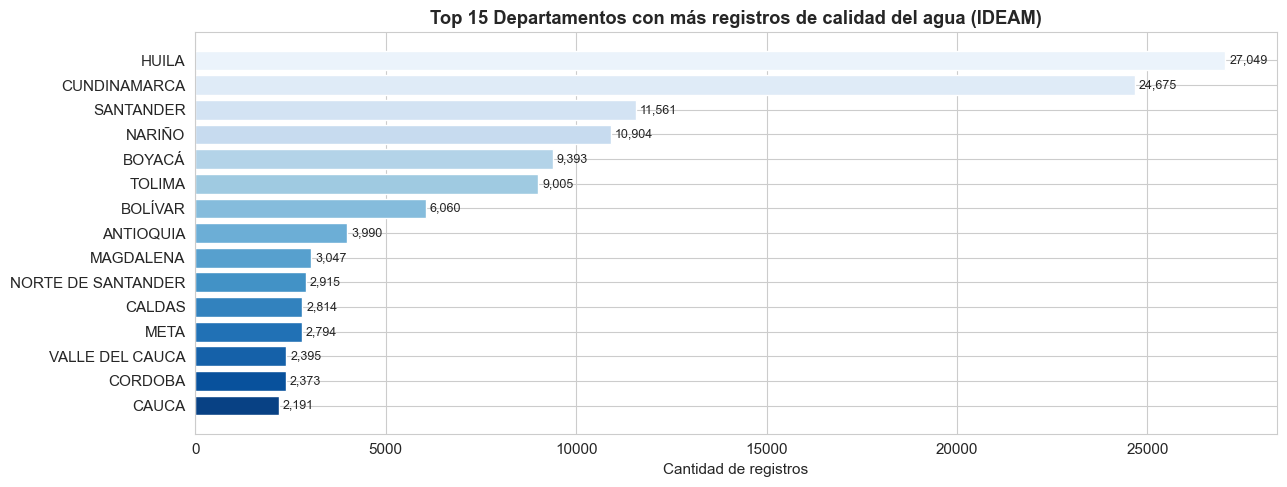

In [8]:
# Top 15 departamentos por cantidad de registros
top_dept = df['DEPARTAMENTO'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(top_dept.index[::-1], top_dept.values[::-1],
               color=sns.color_palette('Blues_r', 15))
ax.set_xlabel('Cantidad de registros')
ax.set_title('Top 15 Departamentos con más registros de calidad del agua (IDEAM)', fontweight='bold')
for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '01_top_departamentos.png'), dpi=150, bbox_inches='tight')
plt.show()

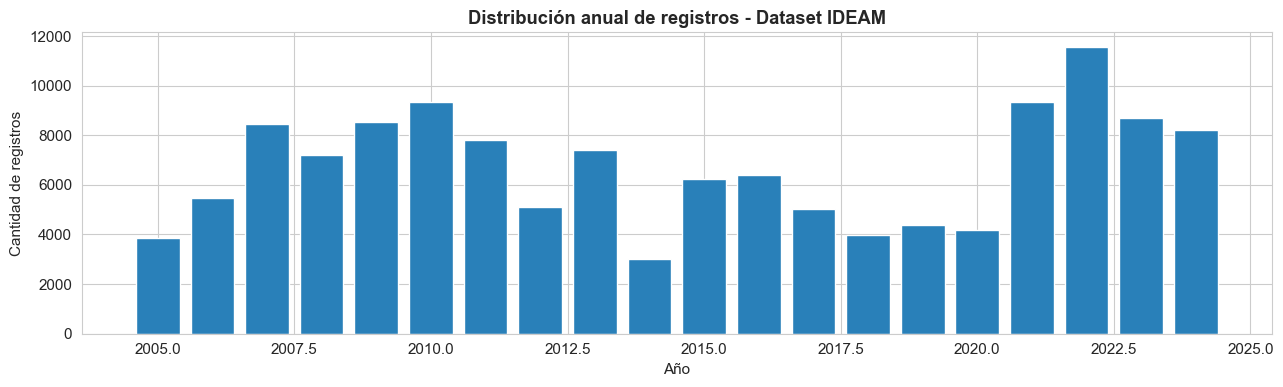

In [9]:
# Distribución temporal de registros
df['FECHA_DT'] = pd.to_datetime(df['FECHA'], errors='coerce')
df['AÑO']      = df['FECHA_DT'].dt.year

anual = df.groupby('AÑO').size()
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(anual.index, anual.values, color='#2980B9', edgecolor='white')
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de registros')
ax.set_title('Distribución anual de registros - Dataset IDEAM', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '01_distribucion_temporal.png'), dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Guardar referencia del dataset para notebooks siguientes
df.to_parquet(os.path.join(BASE_DIR, 'dataset', 'processed', 'raw_cache.parquet'), index=False)
print('Cache guardado en dataset/processed/raw_cache.parquet')
print(f'\nResumen final:')
print(f'  - {df.shape[0]:,} registros totales')
print(f'  - {df["PROPIEDAD OBSERVADA"].nunique()} propiedades únicas medidas')
print(f'  - {df["NOMBRE DEL PUNTO DE MONITOREO"].nunique():,} puntos de monitoreo')
print(f'  - {df["DEPARTAMENTO"].nunique()} departamentos cubiertos')

Cache guardado en dataset/processed/raw_cache.parquet

Resumen final:
  - 134,261 registros totales
  - 80 propiedades únicas medidas
  - 244 puntos de monitoreo
  - 28 departamentos cubiertos
